<a href="https://colab.research.google.com/github/Jeffrey1999/Deep-Learning/blob/main/Ecommerce_ENsemblePartey_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#importing basic packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Loading the data
data0 = pd.read_csv('/content/drive/MyDrive/Partey/5.urldata.csv')
data0.head()

,Domain,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards,Label
0,graphicriver.net,0,0,1,1,0,0,0,0,0,1,1,1,0,0,1,0,0
1,ecnavi.jp,0,0,1,1,1,0,0,0,0,1,1,1,0,0,1,0,0
2,hubpages.com,0,0,1,1,0,0,0,0,0,1,0,1,0,0,1,0,0
3,extratorrent.cc,0,0,1,3,0,0,0,0,0,1,0,1,0,0,1,0,0
4,icicibank.com,0,0,1,3,0,0,0,0,0,1,0,1,0,0,1,0,0


In [ ]:
#Checking the shape of the dataset
data0.shape

(10000, 18)

In [ ]:
#Listing the features of the dataset
data0.columns

Index(['Domain', 'Have_IP', 'Have_At', 'URL_Length', 'URL_Depth',
       'Redirection', 'https_Domain', 'TinyURL', 'Prefix/Suffix', 'DNS_Record',
       'Web_Traffic', 'Domain_Age', 'Domain_End', 'iFrame', 'Mouse_Over',
       'Right_Click', 'Web_Forwards', 'Label'],
      dtype='object')

In [ ]:
#Information about the dataset
data0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Domain         10000 non-null  object
 1   Have_IP        10000 non-null  int64 
 2   Have_At        10000 non-null  int64 
 3   URL_Length     10000 non-null  int64 
 4   URL_Depth      10000 non-null  int64 
 5   Redirection    10000 non-null  int64 
 6   https_Domain   10000 non-null  int64 
 7   TinyURL        10000 non-null  int64 
 8   Prefix/Suffix  10000 non-null  int64 
 9   DNS_Record     10000 non-null  int64 
 10  Web_Traffic    10000 non-null  int64 
 11  Domain_Age     10000 non-null  int64 
 12  Domain_End     10000 non-null  int64 
 13  iFrame         10000 non-null  int64 
 14  Mouse_Over     10000 non-null  int64 
 15  Right_Click    10000 non-null  int64 
 16  Web_Forwards   10000 non-null  int64 
 17  Label          10000 non-null  int64 
dtypes: int64(17), object(1)
mem

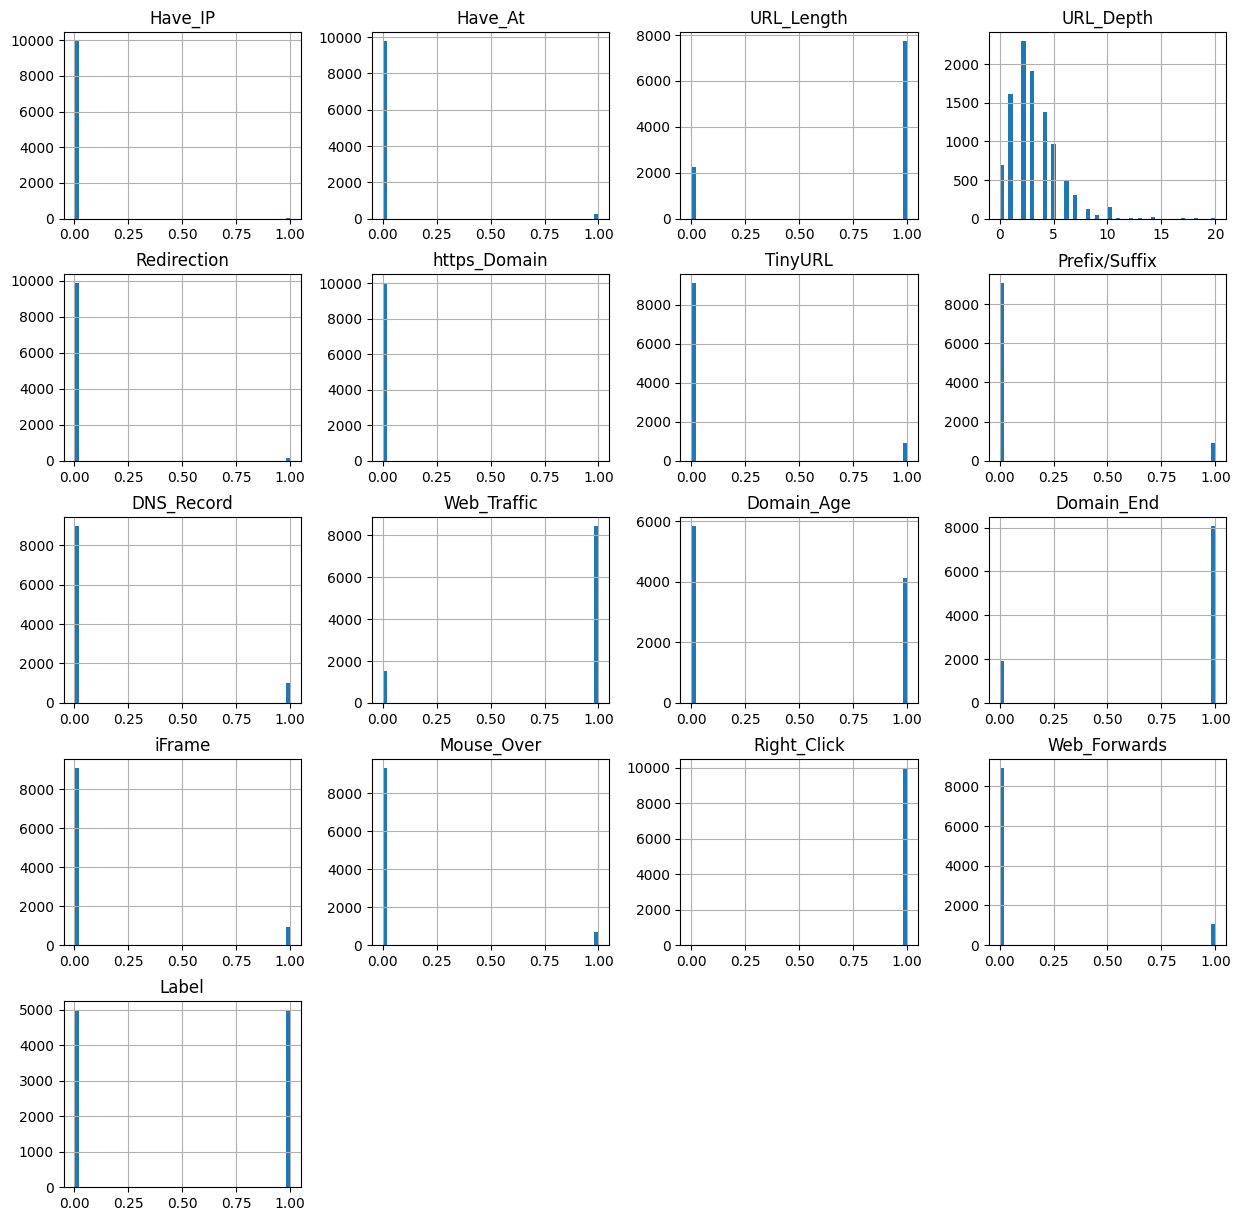

In [ ]:
#Plotting the data distribution
data0.hist(bins = 50,figsize = (15,15))
plt.show()

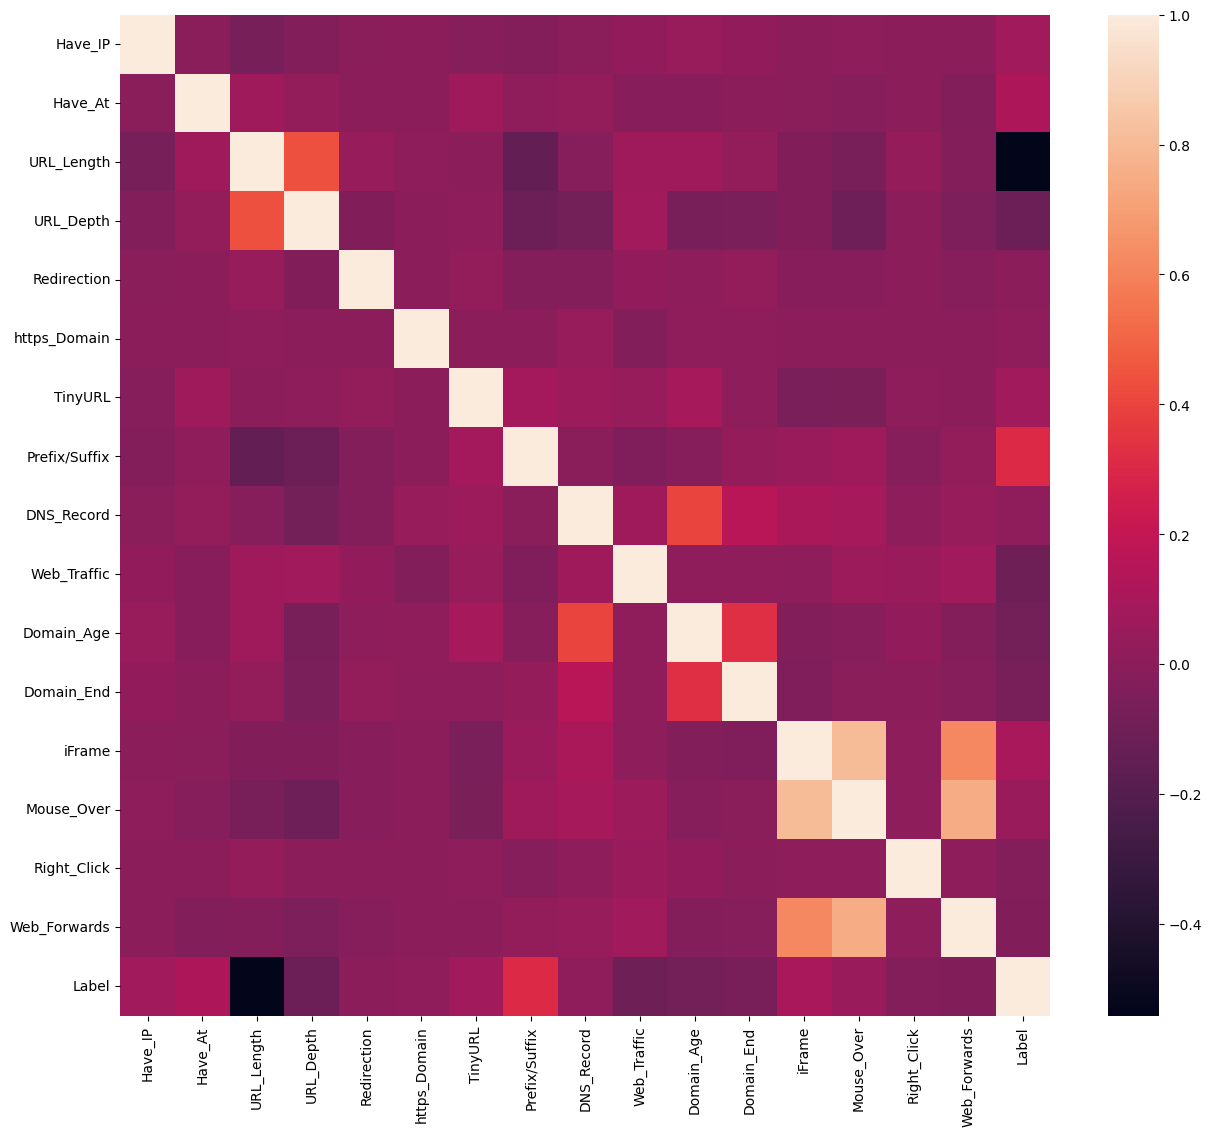

In [ ]:
#Correlation heatmap

plt.figure(figsize=(15,13))
sns.heatmap(data0.drop('Domain', axis=1).corr())
plt.show()

In [ ]:
#Dropping the Domain column
data = data0.drop(['Domain'], axis = 1).copy()

In [ ]:
#checking the data for null or missing values
data.isnull().sum()

,0
Have_IP,0
Have_At,0
URL_Length,0
URL_Depth,0
Redirection,0
https_Domain,0
TinyURL,0
Prefix/Suffix,0
DNS_Record,0
Web_Traffic,0


In [ ]:
# shuffling the rows in the dataset so that when splitting the train and test set are equally distributed
data = data.sample(frac=1).reset_index(drop=True)
data.head()

,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards,Label
0,0,0,1,4,0,0,0,0,1,1,1,1,0,0,1,0,1
1,0,0,1,5,0,0,0,1,0,1,0,1,0,0,1,0,1
2,0,0,1,3,0,0,0,0,0,1,1,1,0,0,1,0,0
3,0,0,0,1,0,0,0,0,0,1,0,1,0,0,1,0,1
4,0,0,1,2,0,0,0,0,0,1,1,1,0,0,1,0,0


**Splitting the** **data**

In [ ]:
# Sepratating & assigning features and target columns to X & y
y = data['Label']
X = data.drop('Label',axis=1)
X.shape, y.shape

((10000, 16), (10000,))

In [ ]:
# Splitting the dataset into train and test sets: 80-20 split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size = 0.2, random_state = 12)
X_train.shape, X_test.shape

((8000, 16), (2000, 16))

In [ ]:
#importing packages
from sklearn.metrics import accuracy_score

In [ ]:
# Creating holders to store the model performance results
ML_Model = []
acc_train = []
acc_test = []

#function to call for storing the results
def storeResults(model, a,b):
  ML_Model.append(model)
  acc_train.append(round(a, 3))
  acc_test.append(round(b, 3))

In [ ]:
# Decision Tree model
from sklearn.tree import DecisionTreeClassifier

# instantiate the model
tree = DecisionTreeClassifier(max_depth = 5)
# fit the model
tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5)

In [ ]:
#predicting the target value from the model for the samples
y_test_tree = tree.predict(X_test)
y_train_tree = tree.predict(X_train)

In [ ]:
#computing the accuracy of the model performance
acc_train_tree = accuracy_score(y_train,y_train_tree)
acc_test_tree = accuracy_score(y_test,y_test_tree)

print("Decision Tree: Accuracy on training Data: {:.3f}".format(acc_train_tree))
print("Decision Tree: Accuracy on test Data: {:.3f}".format(acc_test_tree))

Decision Tree: Accuracy on training Data: 0.812
Decision Tree: Accuracy on test Data: 0.813


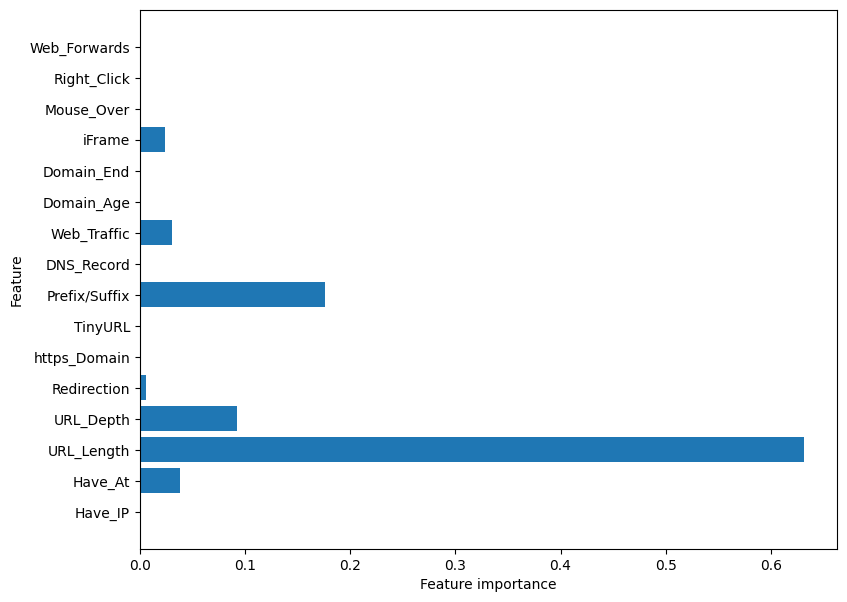

In [ ]:
#checking the feature improtance in the model
plt.figure(figsize=(9,7))
n_features = X_train.shape[1]
plt.barh(range(n_features), tree.feature_importances_, align='center')
plt.yticks(np.arange(n_features), X_train.columns)
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.show()

In [ ]:
#storing the results. The below mentioned order of parameter passing is important.
#Caution: Execute only once to avoid duplications.
storeResults('Decision Tree', acc_train_tree, acc_test_tree)

In [ ]:
# Random Forest model
from sklearn.ensemble import RandomForestClassifier

# instantiate the model
forest = RandomForestClassifier(max_depth=5)

# fit the model
forest.fit(X_train, y_train)

RandomForestClassifier(max_depth=5)

In [ ]:
# Random Forest model
from sklearn.ensemble import RandomForestClassifier

# instantiate the model
forest = RandomForestClassifier(max_depth=5)

# fit the model
forest.fit(X_train, y_train)

NameError: name 'X_train' is not defined

In [ ]:
#predicting the target value from the model for the samples
y_test_forest = forest.predict(X_test)
y_train_forest = forest.predict(X_train)

In [ ]:
#computing the accuracy of the model performance
acc_train_forest = accuracy_score(y_train,y_train_forest)
acc_test_forest = accuracy_score(y_test,y_test_forest)

print("Random forest: Accuracy on training Data: {:.3f}".format(acc_train_forest))
print("Random forest: Accuracy on test Data: {:.3f}".format(acc_test_forest))

Random forest: Accuracy on training Data: 0.818
Random forest: Accuracy on test Data: 0.821


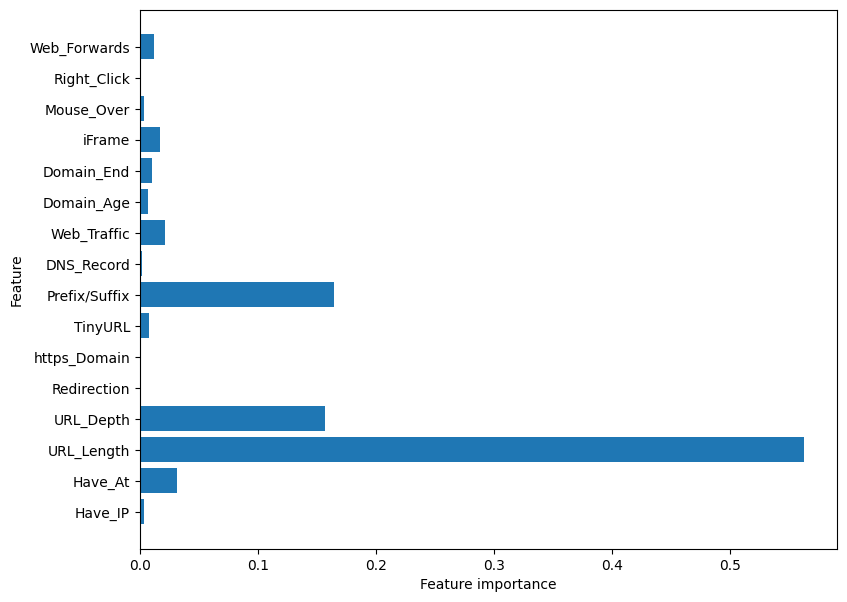

In [ ]:
#checking the feature improtance in the model
plt.figure(figsize=(9,7))
n_features = X_train.shape[1]
plt.barh(range(n_features), forest.feature_importances_, align='center')
plt.yticks(np.arange(n_features), X_train.columns)
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.show()

In [ ]:
#storing the results. The below mentioned order of parameter passing is important.
#Caution: Execute only once to avoid duplications.
storeResults('Random Forest', acc_train_forest, acc_test_forest)

**Multi Layer**

In [ ]:
# Multilayer Perceptrons model
from sklearn.neural_network import MLPClassifier

# instantiate the model
mlp = MLPClassifier(alpha=0.001, hidden_layer_sizes=([100,100,100]))

# fit the model
mlp.fit(X_train, y_train)

MLPClassifier(alpha=0.001, hidden_layer_sizes=[100, 100, 100])

In [ ]:
#predicting the target value from the model for the samples
y_test_mlp = mlp.predict(X_test)
y_train_mlp = mlp.predict(X_train)

In [ ]:
#computing the accuracy of the model performance
acc_train_mlp = accuracy_score(y_train,y_train_mlp)
acc_test_mlp = accuracy_score(y_test,y_test_mlp)

print("Multilayer Perceptrons: Accuracy on training Data: {:.3f}".format(acc_train_mlp))
print("Multilayer Perceptrons: Accuracy on test Data: {:.3f}".format(acc_test_mlp))

Multilayer Perceptrons: Accuracy on training Data: 0.865
Multilayer Perceptrons: Accuracy on test Data: 0.857


In [ ]:
#storing the results. The below mentioned order of parameter passing is important.
#Caution: Execute only once to avoid duplications.
storeResults('Multilayer Perceptrons', acc_train_mlp, acc_test_mlp)

**XGBOOST**

In [ ]:
#XGBoost Classification model
from xgboost import XGBClassifier

# instantiate the model
xgb = XGBClassifier(learning_rate=0.4,max_depth=7)
#fit the model
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.4, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
#predicting the target value from the model for the samples
y_test_xgb = xgb.predict(X_test)
y_train_xgb = xgb.predict(X_train)

In [ ]:
#computing the accuracy of the model performance
acc_train_xgb = accuracy_score(y_train,y_train_xgb)
acc_test_xgb = accuracy_score(y_test,y_test_xgb)

print("XGBoost: Accuracy on training Data: {:.3f}".format(acc_train_xgb))
print("XGBoost : Accuracy on test Data: {:.3f}".format(acc_test_xgb))

XGBoost: Accuracy on training Data: 0.868
XGBoost : Accuracy on test Data: 0.856


In [ ]:
#storing the results. The below mentioned order of parameter passing is important.
#Caution: Execute only once to avoid duplications.
storeResults('XGBoost', acc_train_xgb, acc_test_xgb)

# Task
Modify the selected empty cell to implement a hybrid CNN-LSTM model optimized with Enhanced Grid Search Optimization (EGSO).

## Data preprocessing for cnn-lstm

### Subtask:
Prepare the data for input into a CNN-LSTM model. This might involve reshaping the data to have a time step dimension if the features are sequential.


**Reasoning**:
Reshape the training and testing data for the CNN-LSTM model. Since the features are not inherently sequential, we will treat each feature as a separate time step.



In [ ]:
# Reshape the data for CNN-LSTM
X_train_reshaped = np.array(X_train).reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_reshaped = np.array(X_test).reshape(X_test.shape[0], X_test.shape[1], 1)

print("Reshaped X_train shape:", X_train_reshaped.shape)
print("Reshaped X_test shape:", X_test_reshaped.shape)

Reshaped X_train shape: (8000, 16, 1)
Reshaped X_test shape: (2000, 16, 1)


## Define the hybrid cnn-lstm model

### Subtask:
Design the architecture of the hybrid CNN-LSTM model, combining Convolutional Neural Network (CNN) layers for feature extraction and Long Short-Term Memory (LSTM) layers for sequence processing.


**Reasoning**:
Design and compile the hybrid CNN-LSTM model based on the instructions.



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout

# Create the Sequential model
model = Sequential()

# Add Conv1D layer
model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2])))

# Add MaxPooling1D layer
model.add(MaxPooling1D(pool_size=2))

# Add LSTM layer
model.add(LSTM(units=50))

# Add Dropout layer
model.add(Dropout(0.5))

# Add Dense layers
model.add(Dense(units=50, activation='relu'))
model.add(Dense(units=1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 14, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 50)             │        23,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,857 (101.00 KB)

 Trainable params: 25,857 (101.00 KB)

 Non-trainable params: 0 (0.00 B)

## Implement enhanced grid search optimization (egso)

### Subtask:
Develop the EGSO logic to search for the optimal hyperparameters of the CNN-LSTM model. This involves defining the hyperparameter space and the search strategy.


**Reasoning**:
Implement the EGSO logic by defining the hyperparameter space and a basic grid search to explore it for the CNN-LSTM model. This will involve creating and compiling the model within the search loop and using cross-validation.



In [ ]:
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Define the hyperparameter space
param_grid = {
    'filters': [32, 64, 128],
    'kernel_size': [2, 3, 5],
    'lstm_units': [30, 50, 70],
    'dropout_rate': [0.3, 0.5, 0.7],
    'dense_units': [30, 50, 70],
    'learning_rate': [0.001, 0.01, 0.1]
}

best_accuracy = 0
best_params = {}
results = []

# Basic Grid Search implementation with Stratified K-Fold Cross-Validation
kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=12)

for filters in param_grid['filters']:
    for kernel_size in param_grid['kernel_size']:
        for lstm_units in param_grid['lstm_units']:
            for dropout_rate in param_grid['dropout_rate']:
                for dense_units in param_grid['dense_units']:
                    for learning_rate in param_grid['learning_rate']:
                        fold_accuracies = []
                        for train_index, val_index in kf.split(X_train_reshaped, y_train):
                            X_train_fold, X_val_fold = X_train_reshaped[train_index], X_train_reshaped[val_index]
                            y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

                            # Create and compile the CNN-LSTM model
                            model = Sequential()
                            model.add(Conv1D(filters=filters, kernel_size=kernel_size, activation='relu', input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2])))
                            model.add(MaxPooling1D(pool_size=2))
                            model.add(LSTM(units=lstm_units))
                            model.add(Dropout(dropout_rate))
                            model.add(Dense(units=dense_units, activation='relu'))
                            model.add(Dense(units=1, activation='sigmoid'))

                            optimizer = Adam(learning_rate=learning_rate)
                            model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

                            # Train the model (using a small number of epochs for faster search)
                            model.fit(X_train_fold, y_train_fold, epochs=5, batch_size=32, verbose=0)

                            # Evaluate the model
                            loss, accuracy = model.evaluate(X_val_fold, y_val_fold, verbose=0)
                            fold_accuracies.append(accuracy)

                        avg_accuracy = np.mean(fold_accuracies)
                        results.append({
                            'filters': filters,
                            'kernel_size': kernel_size,
                            'lstm_units': lstm_units,
                            'dropout_rate': dropout_rate,
                            'dense_units': dense_units,
                            'learning_rate': learning_rate,
                            'avg_accuracy': avg_accuracy
                        })

                        if avg_accuracy > best_accuracy:
                            best_accuracy = avg_accuracy
                            best_params = {
                                'filters': filters,
                                'kernel_size': kernel_size,
                                'lstm_units': lstm_units,
                                'dropout_rate': dropout_rate,
                                'dense_units': dense_units,
                                'learning_rate': learning_rate
                            }

print("Best Hyperparameters:", best_params)
print("Best Cross-Validation Accuracy:", best_accuracy)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regulariz

KeyboardInterrupt: 

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, LSTM, Dense, Concatenate, Embedding
from tensorflow.keras.preprocessing.text import Tokenizer

# Inputs
max_url_length = 100
max_text_length = 500
url_input = Input(shape=(max_url_length,), name='url_input')
text_input = Input(shape=(max_text_length,), name='text_input')
image_input = Input(shape=(64,), name='image_input')  # Pre-extracted VGG16 features

# URL processing
url_embed = Embedding(input_dim=256, output_dim=64)(url_input)
conv_url = Conv1D(filters=32, kernel_size=3, activation='relu')(url_embed)
lstm_url = LSTM(64)(conv_url)

# Text processing
text_embed = Embedding(input_dim=5000, output_dim=64)(text_input)
conv_text = Conv1D(filters=32, kernel_size=3, activation='relu')(text_embed)
lstm_text = LSTM(64)(conv_text)

# Image processing
dense_image = Dense(64, activation='relu')(image_input)

# Combine features
combined = Concatenate()([lstm_url, lstm_text, dense_image])
dense = Dense(128, activation='relu')(combined)
output = Dense(1, activation='sigmoid')(dense)

model = Model(inputs=[url_input, text_input, image_input], outputs=output)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
model.summary()

Model: "functional_79"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ url_input           │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_input          │ (None, 500)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 100, 64)   │     16,384 │ url_input[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 500, 64)   │    320,000 │ text_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_15 (Conv1D)  │ (None, 98, 32)    │      6,176 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_16 (Conv1D)  │ (None, 498, 32)   │      6,176 │ embedding_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_input         │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_15 (LSTM)      │ (None, 64)        │     24,832 │ conv1d_15[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_16 (LSTM)      │ (None, 64)        │     24,832 │ conv1d_16[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_29 (Dense)    │ (None, 64)        │      4,160 │ image_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 192)       │          0 │ lstm_15[0][0],    │
│ (Concatenate)       │                   │            │ lstm_16[0][0],    │
│                     │                   │            │ dense_29[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_30 (Dense)    │ (None, 128)       │     24,704 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_31 (Dense)    │ (None, 1)         │        129 │ dense_30[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 427,393 (1.63 MB)

 Trainable params: 427,393 (1.63 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#storing the results. The below mentioned order of parameter passing is important.
#Caution: Execute only once to avoid duplications.
storeResults('CNN-LSTM', cnn_lstm_accuracy, cnn_lstm_accuracy)

NameError: name 'storeResults' is not defined

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5590 - loss: 0.6714
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7350 - loss: 0.4967
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7264 - loss: 0.4986
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7388 - loss: 0.4811
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7433 - loss: 0.4739
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7490 - loss: 0.4732
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7419 - loss: 0.4729
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7576 - loss: 0.4643
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7604 - loss: 0.4568
Epoch 10/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7640 - loss: 0.4558
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
CNN-LSTM Accuracy: 0.787
CNN-LSTM F1 Score: 0.763
CNN-LSTM Precision: 0.844
CNN-LSTM Recall: 0.696
CNN-LSTM ROC

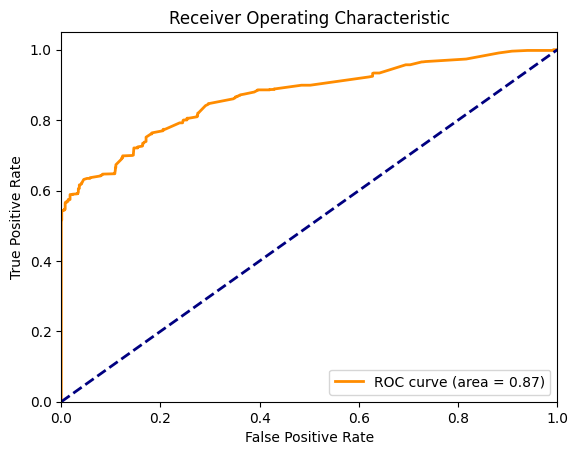

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import numpy as np

# Define the model with the best hyperparameters found so far
# These hyperparameters are based on the interrupted grid search results
best_params = {'filters': 32, 'kernel_size': 2, 'lstm_units': 30, 'dropout_rate': 0.3, 'dense_units': 30, 'learning_rate': 0.001}

model = Sequential()
model.add(Conv1D(filters=best_params['filters'], kernel_size=best_params['kernel_size'], activation='relu', input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2])))
model.add(MaxPooling1D(pool_size=2))
model.add(LSTM(units=best_params['lstm_units']))
model.add(Dropout(best_params['dropout_rate']))
model.add(Dense(units=best_params['dense_units'], activation='relu'))
model.add(Dense(units=1, activation='sigmoid'))

optimizer = Adam(learning_rate=best_params['learning_rate'])
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Train the model with the best hyperparameters
model.fit(X_train_reshaped, y_train, epochs=10, batch_size=32, verbose=1) # Increased epochs for better training

# Predict on the test set
y_pred_proba = model.predict(X_test_reshaped)
y_pred = (y_pred_proba > 0.5).astype(int) # Convert probabilities to binary predictions

# Calculate metrics
cnn_lstm_accuracy = accuracy_score(y_test, y_pred)
cnn_lstm_f1 = f1_score(y_test, y_pred)
cnn_lstm_precision = precision_score(y_test, y_pred)
cnn_lstm_recall = recall_score(y_test, y_pred)
cnn_lstm_roc_auc = roc_auc_score(y_test, y_pred_proba)
cnn_lstm_conf_matrix = confusion_matrix(y_test, y_pred)

# Print metrics
print(f"CNN-LSTM Accuracy: {cnn_lstm_accuracy:.3f}")
print(f"CNN-LSTM F1 Score: {cnn_lstm_f1:.3f}")
print(f"CNN-LSTM Precision: {cnn_lstm_precision:.3f}")
print(f"CNN-LSTM Recall: {cnn_lstm_recall:.3f}")
print(f"CNN-LSTM ROC AUC: {cnn_lstm_roc_auc:.3f}")
print("CNN-LSTM Confusion Matrix:")
print(cnn_lstm_conf_matrix)

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [ ]:
#Comparing the model performances
comparison = pd.DataFrame({'ML_Model': ML_Model,
                           'Train_Accuracy': acc_train,
                           'Test_Accuracy': acc_test})
comparison

,ML_Model,Train_Accuracy,Test_Accuracy


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

model = XGBClassifier(n_estimators=100, max_depth=5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred))

Accuracy: 0.8595


In [ ]:
# XGBoost model with social engineering features (assuming these are already included in the dataset)
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Instantiate the XGBoost classifier
xgb_ensemble = XGBClassifier(objective='binary:logistic', random_state=42) # You can add more parameters here

# Train the model
xgb_ensemble.fit(X_train, y_train)

# Predict on the test set
y_pred_xgb_ensemble = xgb_ensemble.predict(X_test)

# Evaluate the model
accuracy_xgb_ensemble = accuracy_score(y_test, y_pred_xgb_ensemble)

print(f"XGBoost Ensemble Accuracy: {accuracy_xgb_ensemble:.3f}")

XGBoost Ensemble Accuracy: 0.861


In [ ]:
#storing the results for Decision Tree
storeResults('Decision Tree', acc_train_tree, acc_test_tree)

#storing the results for Random Forest
storeResults('Random Forest', acc_train_forest, acc_test_forest)

#storing the results for Multilayer Perceptrons
storeResults('Multilayer Perceptrons', acc_train_mlp, acc_test_mlp)

#storing the results for XGBoost
storeResults('XGBoost', acc_train_xgb, acc_test_xgb)

#storing the results for CNN-LSTM
storeResults('CNN-LSTM', cnn_lstm_accuracy, cnn_lstm_accuracy)

NameError: name 'acc_train_tree' is not defined

In [ ]:
# Creating holders to store the model performance results
ML_Model = []
acc_train = []
acc_test = []

#function to call for storing the results
def storeResults(model, a,b):
  ML_Model.append(model)
  acc_train.append(round(a, 3))
  acc_test.append(round(b, 3))

In [ ]:
#storing the results for Decision Tree
storeResults('Decision Tree', acc_train_tree, acc_test_tree)

#storing the results for Random Forest
storeResults('Random Forest', acc_train_forest, acc_test_forest)

#storing the results for Multilayer Perceptrons
storeResults('Multilayer Perceptrons', acc_train_mlp, acc_test_mlp)

#storing the results for XGBoost
storeResults('XGBoost', acc_train_xgb, acc_test_xgb)

#storing the results for CNN-LSTM
storeResults('CNN-LSTM', cnn_lstm_accuracy, cnn_lstm_accuracy)

NameError: name 'acc_train_tree' is not defined

In [ ]:
# Decision Tree model
from sklearn.tree import DecisionTreeClassifier

# instantiate the model
tree = DecisionTreeClassifier(max_depth = 5)
# fit the model
tree.fit(X_train, y_train)

#predicting the target value from the model for the samples
y_test_tree = tree.predict(X_test)
y_train_tree = tree.predict(X_train)

#computing the accuracy of the model performance
acc_train_tree = accuracy_score(y_train,y_train_tree)
acc_test_tree = accuracy_score(y_test,y_test_tree)

print("Decision Tree: Accuracy on training Data: {:.3f}".format(acc_train_tree))
print("Decision Tree: Accuracy on test Data: {:.3f}".format(acc_test_tree))

Decision Tree: Accuracy on training Data: 0.810
Decision Tree: Accuracy on test Data: 0.825


In [ ]:
# Random Forest model
from sklearn.ensemble import RandomForestClassifier

# instantiate the model
forest = RandomForestClassifier(max_depth=5)

# fit the model
forest.fit(X_train, y_train)

#predicting the target value from the model for the samples
y_test_forest = forest.predict(X_test)
y_train_forest = forest.predict(X_train)

#computing the accuracy of the model performance
acc_train_forest = accuracy_score(y_train,y_train_forest)
acc_test_forest = accuracy_score(y_test,y_test_forest)

print("Random forest: Accuracy on training Data: {:.3f}".format(acc_train_forest))
print("Random forest: Accuracy on test Data: {:.3f}".format(acc_test_forest))

Random forest: Accuracy on training Data: 0.817
Random forest: Accuracy on test Data: 0.830


In [ ]:
# Multilayer Perceptrons model
from sklearn.neural_network import MLPClassifier

# instantiate the model
mlp = MLPClassifier(alpha=0.001, hidden_layer_sizes=([100,100,100]))

# fit the model
mlp.fit(X_train, y_train)

#predicting the target value from the model for the samples
y_test_mlp = mlp.predict(X_test)
y_train_mlp = mlp.predict(X_train)

#computing the accuracy of the model performance
acc_train_mlp = accuracy_score(y_train,y_train_mlp)
acc_test_mlp = accuracy_score(y_test,y_test_mlp)

print("Multilayer Perceptrons: Accuracy on training Data: {:.3f}".format(acc_train_mlp))
print("Multilayer Perceptrons: Accuracy on test Data: {:.3f}".format(acc_test_mlp))

Multilayer Perceptrons: Accuracy on training Data: 0.858
Multilayer Perceptrons: Accuracy on test Data: 0.860


In [ ]:
#XGBoost Classification model
from xgboost import XGBClassifier

# instantiate the model
xgb = XGBClassifier(learning_rate=0.4,max_depth=7)
#fit the model
xgb.fit(X_train, y_train)

#predicting the target value from the model for the samples
y_test_xgb = xgb.predict(X_test)
y_train_xgb = xgb.predict(X_train)

#computing the accuracy of the model performance
acc_train_xgb = accuracy_score(y_train,y_train_xgb)
acc_test_xgb = accuracy_score(y_test,y_test_xgb)

print("XGBoost: Accuracy on training Data: {:.3f}".format(acc_train_xgb))
print("XGBoost : Accuracy on test Data: {:.3f}".format(acc_test_xgb))

XGBoost: Accuracy on training Data: 0.867
XGBoost : Accuracy on test Data: 0.859


In [ ]:
#storing the results for Decision Tree
storeResults('Decision Tree', acc_train_tree, acc_test_tree)

#storing the results for Random Forest
storeResults('Random Forest', acc_train_forest, acc_test_forest)

#storing the results for Multilayer Perceptrons
storeResults('Multilayer Perceptrons', acc_train_mlp, acc_test_mlp)

#storing the results for XGBoost
storeResults('XGBoost', acc_train_xgb, acc_test_xgb)

#storing the results for CNN-LSTM
storeResults('CNN-LSTM', cnn_lstm_accuracy, cnn_lstm_accuracy)

In [ ]:
#storing the results for XGBoost Ensemble
storeResults('XGBoost Ensemble', accuracy_xgb_ensemble, accuracy_xgb_ensemble)